# Qiskit 02- Multiple Systems 

## Tensor products

In [1]:
from qiskit import __version__
print(__version__)
import numpy as np
from qiskit.quantum_info import Statevector, Operator
from numpy import sqrt

1.3.1


该 `Statevector` 类有一个 `tensor` 方法，该方法返回该方法 `Statevector` 与另一个方法的张量积，作为参数给出。

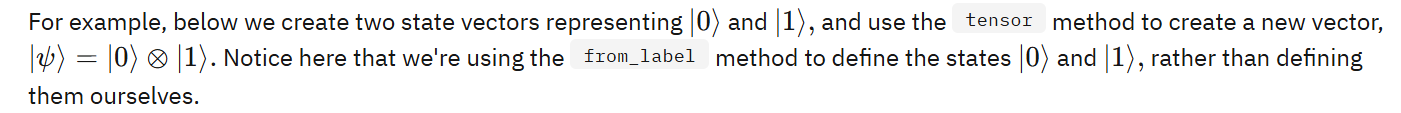

In [2]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero.tensor(one)
display(zero.draw("latex"))
display(psi.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Other allowed labels include "+" and "-" for the plus and minus states, as well as "r" and "l" (short for "right" and "left") for the states:

In [ ]:
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
phi = plus.tensor(minus_i)
display(phi.draw("latex"))

<IPython.core.display.Latex object>

An alternative is to use the `^` operation for tensor products, which naturally gives the same results.

In [4]:
display((plus ^ minus_i).draw("latex"))

<IPython.core.display.Latex object>

该 `Operator` 类还有一个 `tensor` 方法（以及一个 `from_label` 方法），如以下示例所示:

In [5]:
H = Operator.from_label("H")
I = Operator.from_label("I")
X = Operator.from_label("X")
display(H.tensor(I).draw("latex"))
display(H.tensor(I).tensor(X).draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

同样，与 vector 情况一样，该 `^` 作是等效的。

In [6]:
display((H ^ I ^ X).draw("latex"))

<IPython.core.display.Latex object>

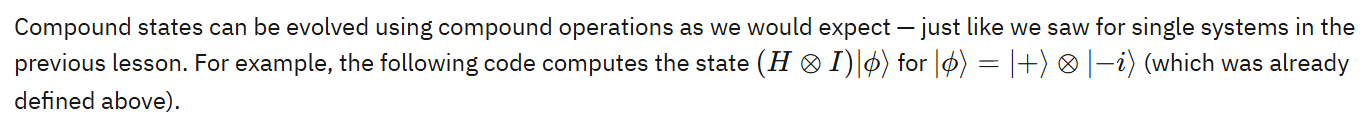

In [7]:
display(phi.evolve(H ^ I).draw("latex"))

<IPython.core.display.Latex object>

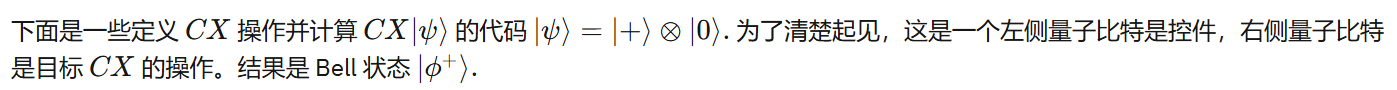

In [8]:
CX = Operator(
    [[1, 0, 0, 0],
     [0, 1, 0, 0],
     [0, 0, 0, 1],
     [0, 0, 1, 0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))

<IPython.core.display.Latex object>

## Partial measurements

- 单系统中 `measure` 模拟量子状态向量的测量。此方法返回两项：模拟的测量结果和给定此测量的新 `Statevector` 结果。
- 默认情况下， measure 测量 state 向量中的所有量子比特。
- Qiskit numbers qubits starting from 0, `from right to left`.

In [19]:
w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / sqrt(3))
display(w.draw("latex"))
# 在此可以看清编号是什么：
w1 = Statevector([1, 1, 1, 1, 1, 1, 1, 1])
display(w1.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [24]:
# 测量量子比特编号 0，即最右侧的量子比特。（Qiskit 从右到左对量子比特进行编号。)
result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

result, state = w.measure([0,1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

result, state = w.measure([0,1,2])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

Measured: 0
State after measurement:


<IPython.core.display.Latex object>

Measured: 10
State after measurement:


<IPython.core.display.Latex object>

Measured: 100
State after measurement:


<IPython.core.display.Latex object>